# Who Said It? — EDA & Preprocessing

6 years of Discord messages, Naive Bayes classifier.  
This notebook covers exploratory data analysis and text preprocessing, producing a clean dataset ready for training.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_PATH = '../data/messages.csv'
MIN_MESSAGES = 200  # drop authors below this threshold

## 1. Load & Initial Inspection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (54240, 8)


,channel_name,message_id,author_username,author_display_name,created_at_iso,content,is_bot,attachments
0,general,755304415908593745,justfresher,CGL MAFDY,2020-09-15T05:50:05.630000+00:00,Lets gooo,False,NaN
1,general,755304483629695076,punkkluvv,punkk,2020-09-15T05:50:21.776000+00:00,god damn,False,NaN
2,general,755304539715797052,punkkluvv,punkk,2020-09-15T05:50:35.148000+00:00,<:xqcKek:721970293203009636> \,False,NaN
3,general,755304562746720356,punkkluvv,punkk,2020-09-15T05:50:40.639000+00:00,https://tenor.com/view/wtf-blink-steve-harvey-...,False,NaN
4,general,755304677108744262,justfresher,CGL MAFDY,2020-09-15T05:51:07.905000+00:00,https://tenor.com/view/stanley-sleeping-the-of...,False,NaN


In [3]:
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

channel_name               str
message_id               int64
author_username            str
author_display_name        str
created_at_iso             str
content                    str
is_bot                    bool
attachments            float64
dtype: object

Null counts:
channel_name               0
message_id                 0
author_username            0
author_display_name        0
created_at_iso             0
content                    2
is_bot                     0
attachments            54240
dtype: int64


## 2. Filter Authors

In [4]:
# Use display name as the label
author_counts = df['author_display_name'].value_counts()
print('All authors:')
print(author_counts.to_string())

keep = author_counts[author_counts >= MIN_MESSAGES].index
df = df[df['author_display_name'].isin(keep)].copy()
print(f'\nKept {len(keep)} authors, {len(df)} messages')

All authors:
author_display_name
CGL MAFDY             11751
Davey                 10809
punkk                  8899
CGL THE DRINK          7366
BOOTY GANG CAPTIAN     5476
boat                   4869
thetruemid             3463
Chip                   1330
Ary‼                    130
SIG                     111
Japopo                   36

Kept 8 authors, 53963 messages


## 3. EDA

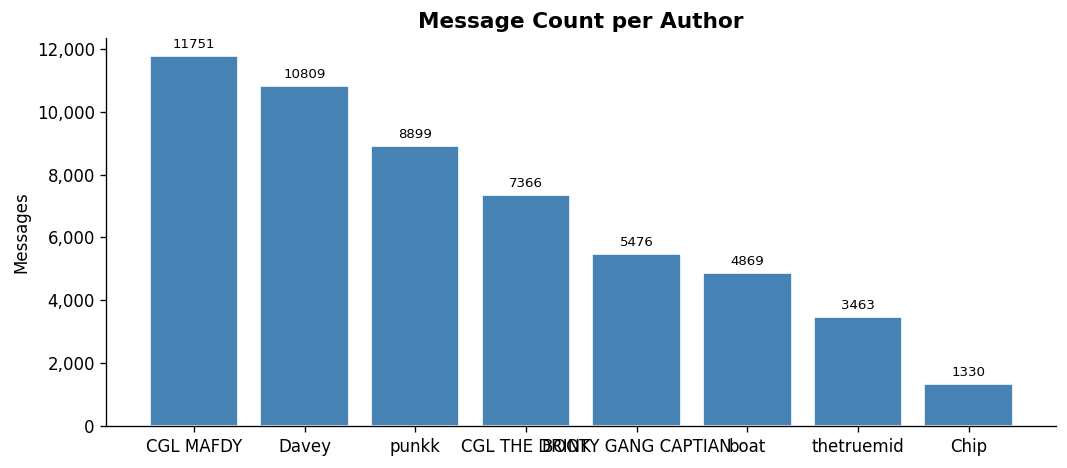

Class imbalance ratio (max/min): 8.84


In [5]:
# --- Message counts per author ---
counts = df['author_display_name'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Message Count per Author', fontsize=13, fontweight='bold')
ax.set_ylabel('Messages')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print('Class imbalance ratio (max/min):', round(counts.max() / counts.min(), 2))

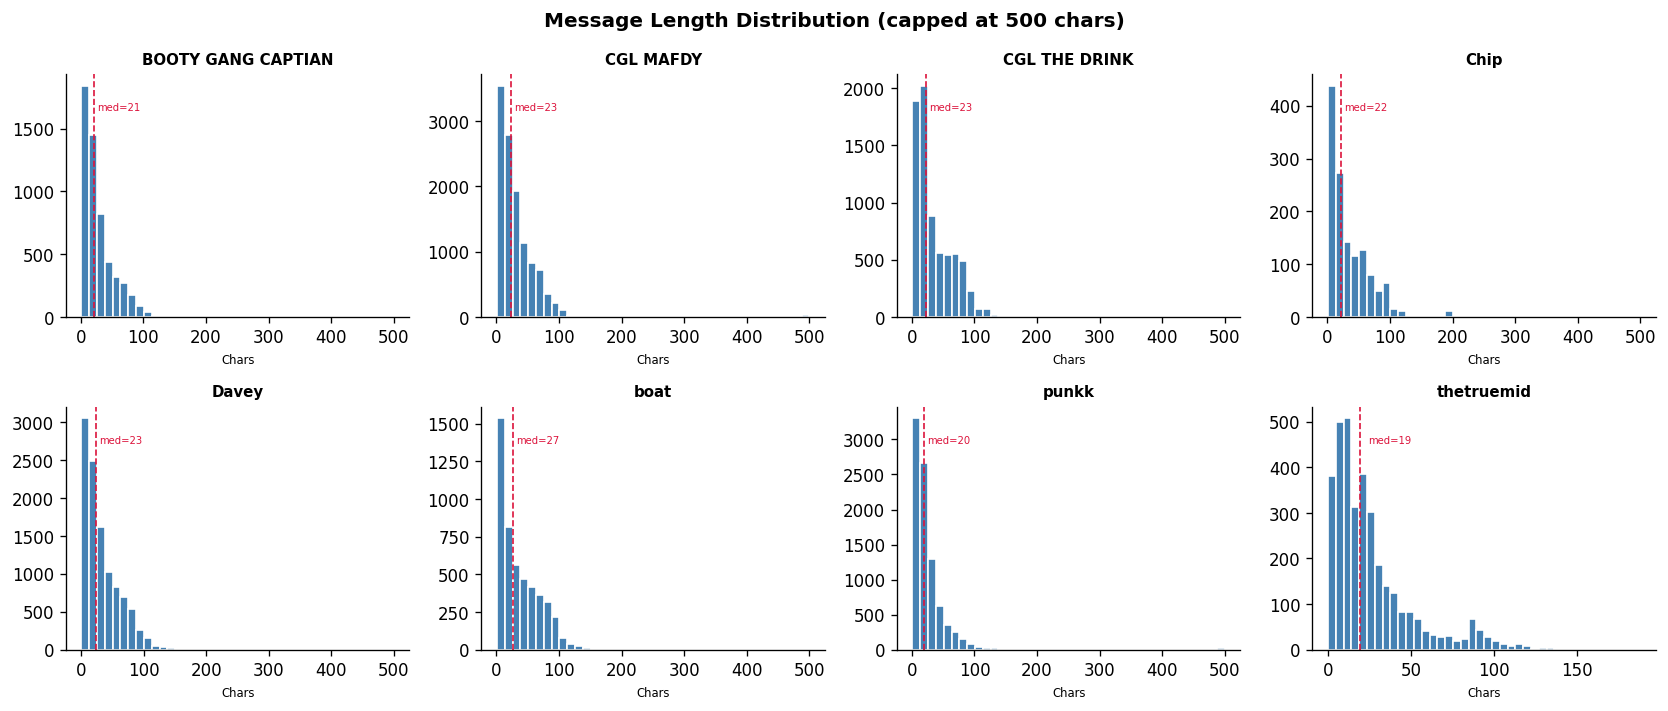

In [6]:
# --- Message length distribution ---
df['msg_len'] = df['content'].fillna('').astype(str).str.len()

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for i, (author, grp) in enumerate(df.groupby('author_display_name')):
    lengths = grp['msg_len'].clip(upper=500)
    axes[i].hist(lengths, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(author, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Chars', fontsize=7)
    median = lengths.median()
    axes[i].axvline(median, color='crimson', linestyle='--', linewidth=1)
    axes[i].text(median + 5, axes[i].get_ylim()[1] * 0.85, f'med={int(median)}', fontsize=6, color='crimson')

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Message Length Distribution (capped at 500 chars)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_80829/935149935.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['created_at'].dt.to_period('M')


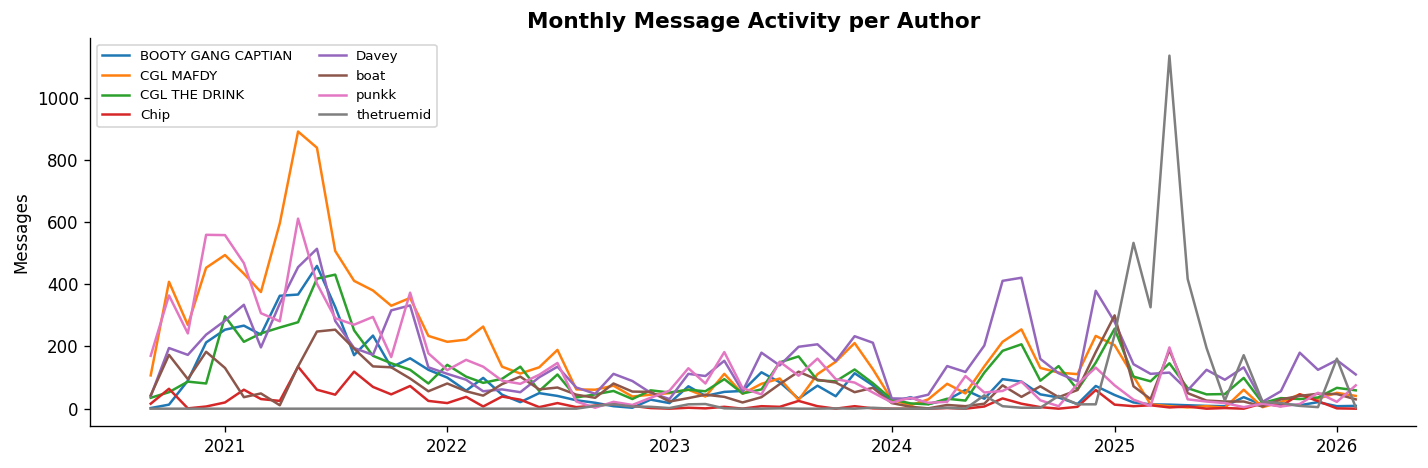

In [7]:
# --- Activity over time ---
df['created_at'] = pd.to_datetime(df['created_at_iso'], format='mixed', utc=True)
df['month'] = df['created_at'].dt.to_period('M')

monthly = df.groupby(['month', 'author_display_name']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
for col in monthly.columns:
    ax.plot(monthly.index, monthly[col], label=col, linewidth=1.5)

ax.set_title('Monthly Message Activity per Author', fontsize=13, fontweight='bold')
ax.set_ylabel('Messages')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

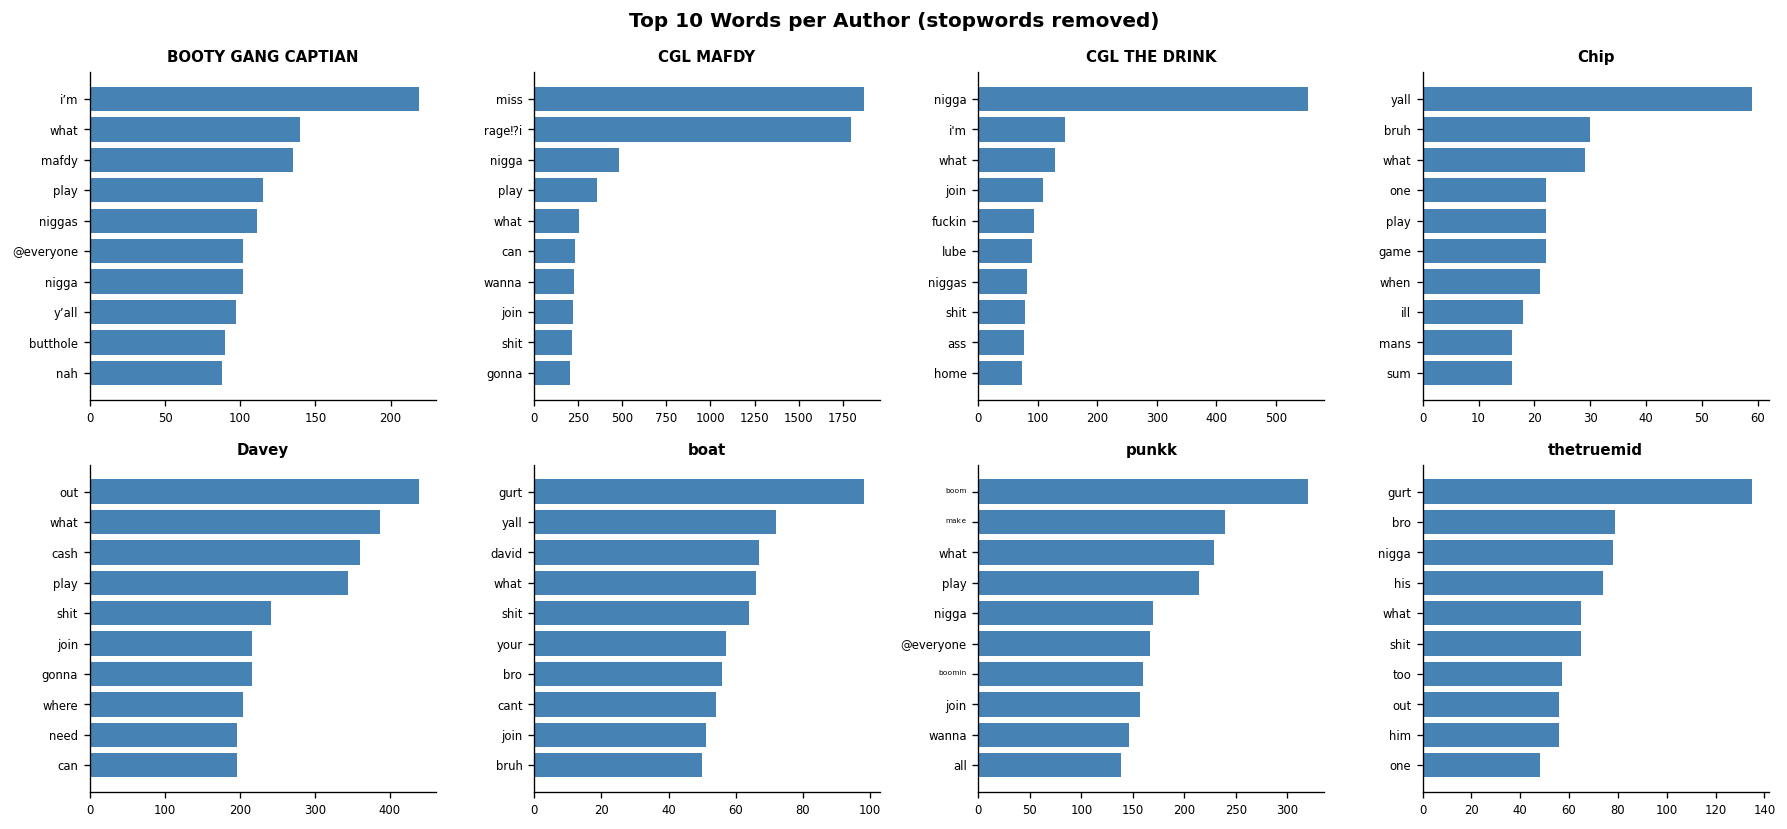

In [8]:
# --- Top words per author (raw, before cleaning) ---
from collections import Counter

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','it',
    'i','you','he','she','they','we','that','this','was','be','have','do','not',
    'with','are','my','so','just','like','its','as','if','yeah','yea','no','yes',
    'im','ive','its','ur','u','lol','lmao','oh','ok','okay','go','get','got'
}

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, (author, grp) in enumerate(df.groupby('author_display_name')):
    words = ' '.join(grp['content'].fillna('').astype(str)).lower().split()
    words = [w.strip('.,!?;:\'"()[]') for w in words if w not in STOPWORDS and len(w) > 2 and not w.startswith('<') and not w.startswith('http')]
    top = Counter(words).most_common(10)
    if not top:
        continue
    labels, vals = zip(*top)
    axes[i].barh(labels[::-1], vals[::-1], color='steelblue')
    axes[i].set_title(author, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 10 Words per Author (stopwords removed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [9]:
def clean_text(text: str) -> str:
    """Normalise a Discord message for classification."""
    if not isinstance(text, str):
        return ''
    # remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # remove Discord custom emoji  <:name:id>
    text = re.sub(r'<:[a-zA-Z0-9_]+:\d+>', '', text)
    # remove Discord mentions  <@id>  <#id>  <@!id>
    text = re.sub(r'<[@#!&]?\d+>', '', text)
    # remove non-ASCII (covers most Unicode emoji)
    text = text.encode('ascii', errors='ignore').decode()
    # collapse whitespace and lower-case
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

# sanity check
samples = [
    'Check this out https://tenor.com/view/wtf-gif-123',
    '<:xqcKek:721970293203009636> bro that was crazy',
    'hey <@!123456789> whats good',
]
for s in samples:
    print(repr(s), '->', repr(clean_text(s)))

'Check this out https://tenor.com/view/wtf-gif-123' -> 'check this out'
'<:xqcKek:721970293203009636> bro that was crazy' -> 'bro that was crazy'
'hey <@!123456789> whats good' -> 'hey <@!123456789> whats good'


In [10]:
df['clean_content'] = df['content'].apply(clean_text)

# drop rows that are empty after cleaning (pure URLs, emoji-only, etc.)
before = len(df)
df = df[df['clean_content'].str.strip() != ''].copy()
print(f'Dropped {before - len(df)} empty rows after cleaning. Remaining: {len(df)}')

Dropped 12010 empty rows after cleaning. Remaining: 41953


In [11]:
# Preview cleaned vs raw
df[['author_display_name', 'content', 'clean_content']].sample(10, random_state=42)

,author_display_name,content,clean_content
26928,CGL MAFDY,I wish I could,i wish i could
23186,boat,stayed home felt a lil under the weather as th...,stayed home felt a lil under the weather as th...
5990,CGL THE DRINK,no,no
50860,Chip,somehow,somehow
10938,BOOTY GANG CAPTIAN,Bro I got so hyped until I read “mod”,bro i got so hyped until i read mod
21663,Davey,Goodnight,goodnight
9900,Davey,Damn,damn
50029,boat,in-n-gurt,in-n-gurt
23468,Davey,Nigga I shit you not this dude just talked abo...,nigga i shit you not this dude just talked abo...
43359,CGL THE DRINK,ARE YOU HERE?,are you here?


## 5. Save Clean Dataset

In [12]:
out = df[['author_display_name', 'clean_content']].rename(columns={'author_display_name': 'author'})
out.to_csv('../data/messages_clean.csv', index=False)
print(f'Saved {len(out)} rows to data/messages_clean.csv')
out['author'].value_counts()

Saved 41953 rows to data/messages_clean.csv


author
CGL MAFDY             9570
Davey                 8261
punkk                 7772
CGL THE DRINK         4619
BOOTY GANG CAPTIAN    4469
boat                  3188
thetruemid            3149
Chip                   925
Name: count, dtype: int64